# Canonical Cortical Column Dynamics

**SC-NeuroCore v3.14** — Five-population laminar microcircuit.

The `CorticalColumn` implements the canonical cortical microcircuit
(Douglas & Martin 1991) with five neuron populations:

```
Thalamus → L4 (feedforward)
L4 → L2/3 exc (feedforward)
L2/3 exc ↔ L2/3 inh (recurrent + inhibition)
L2/3 → L5 (top-down)
L5 → L6 (deep output)
L6 → L4 (feedback / gain control)
```

This notebook demonstrates:
1. **Thalamic drive** — feedforward activation through layers
2. **Layer-resolved spike rasters** — activity per population
3. **Gain control** — L6→L4 feedback modulates responsiveness
4. **Oscillation analysis** — population rate spectra

> © 1998–2026 Miroslav Šotek. All rights reserved.  
> License: GNU AFFERO GENERAL PUBLIC LICENSE v3 | Commercial Licensing Available  
> Contact: www.anulum.li | protoscience@anulum.li

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sc_neurocore.network.cortical_column import CorticalColumn

print("SC-NeuroCore cortical column demo")

SC-NeuroCore cortical column demo


## 1. Build and Drive the Column

In [2]:
col = CorticalColumn(
    n_per_layer=30,
    tau=10.0,
    dt=1.0,
    w_exc=0.1,
    w_inh=-0.15,
    threshold=1.0,
    seed=42,
)

T = 500  # 500 ms

# Thalamic input: Poisson burst for 100 ms, then silence, then sustained
rng = np.random.default_rng(42)
n_thalamic = col.n_per_layer
thalamic = np.zeros((T, n_thalamic))
for t in range(T):
    if 50 < t < 150:  # burst
        thalamic[t] = (rng.random(n_thalamic) < 0.3).astype(float) * 2.0
    elif 300 < t < 500:  # sustained
        thalamic[t] = (rng.random(n_thalamic) < 0.1).astype(float) * 1.5

# Run step by step with varying thalamic input
populations = ['l23_exc', 'l23_inh', 'l4', 'l5', 'l6']
result = {k: [] for k in populations}
for t in range(T):
    out = col.step(thalamic[t])
    for k in populations:
        result[k].append(out[k])
result = {k: np.array(v) for k, v in result.items()}

populations = ['l23_exc', 'l23_inh', 'l4', 'l5', 'l6']
pop_labels = ['L2/3 Exc', 'L2/3 Inh', 'L4', 'L5', 'L6']

for pop, label in zip(populations, pop_labels):
    data = result[pop]
    n_spikes = int(data.sum())
    rate = n_spikes / (T * 0.001 * col.n_per_layer)
    print(f"{label:>10s}: {n_spikes:5d} spikes ({rate:.1f} Hz)")

  L2/3 Exc:     0 spikes (0.0 Hz)
  L2/3 Inh:     0 spikes (0.0 Hz)
        L4:     0 spikes (0.0 Hz)
        L5:     0 spikes (0.0 Hz)
        L6:     0 spikes (0.0 Hz)


## 2. Layer-Resolved Spike Rasters

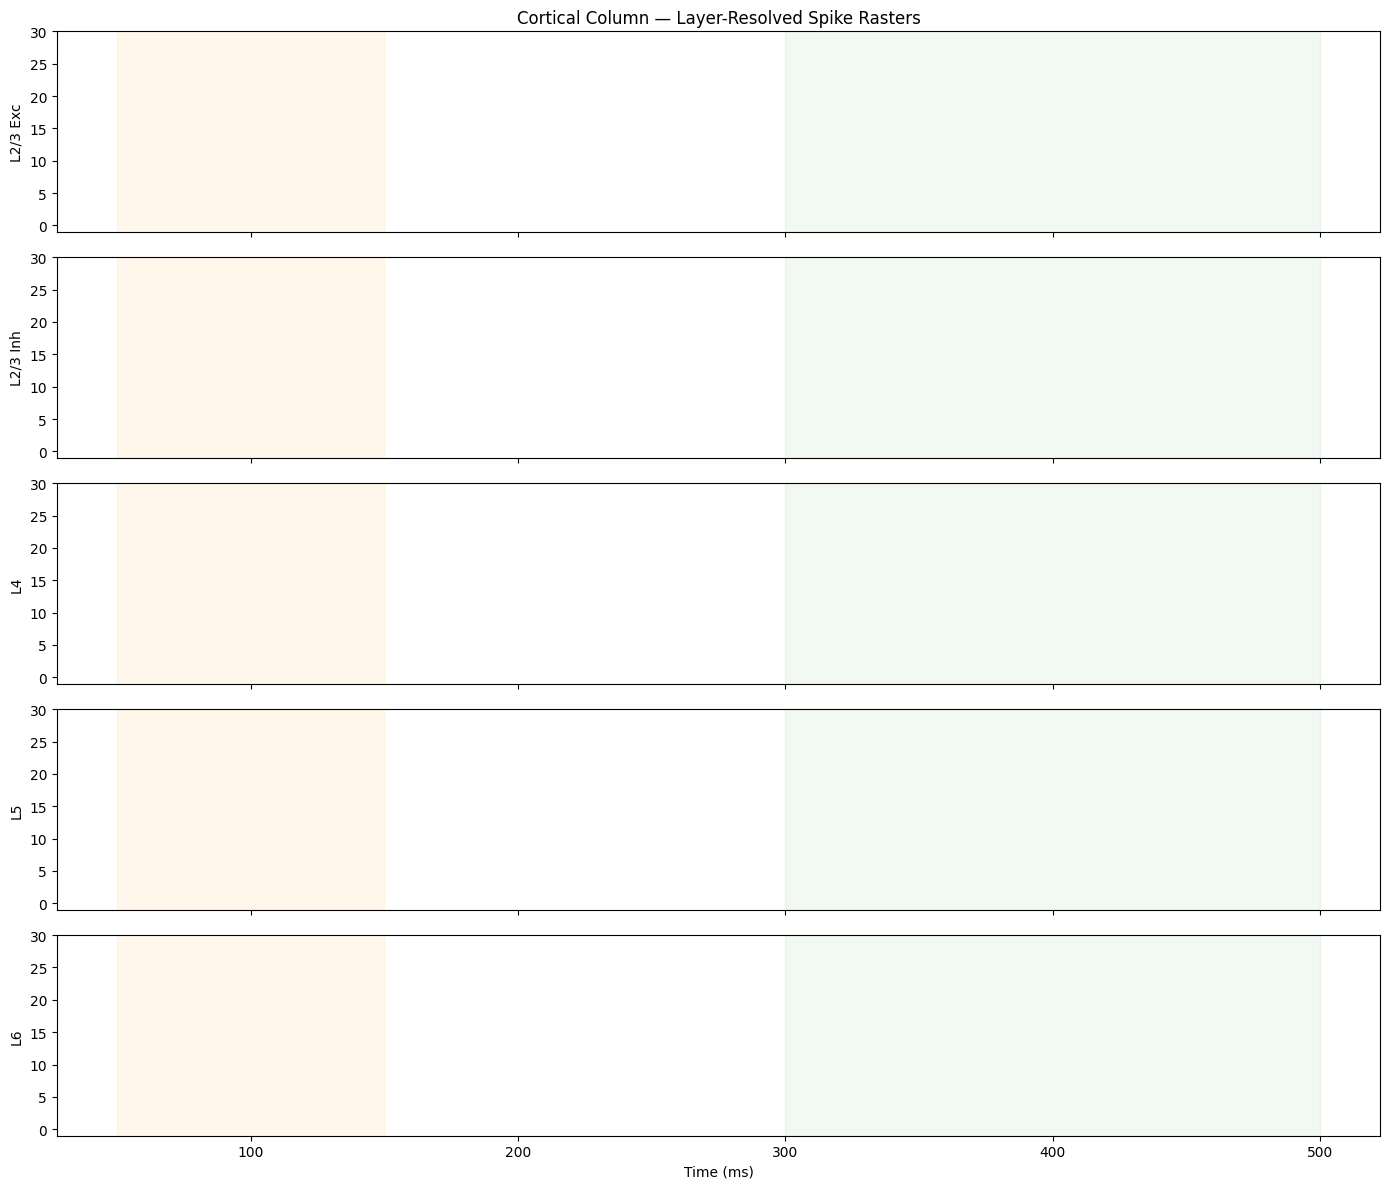

In [3]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
colours = ['#2563EB', '#DC2626', '#059669', '#D97706', '#7C3AED']

for ax, pop, label, colour in zip(axes, populations, pop_labels, colours):
    data = result[pop]  # (T, n_per_layer)
    for n in range(data.shape[1]):
        times = np.where(data[:, n] > 0)[0]
        ax.scatter(times, [n] * len(times), s=0.5, c=colour, alpha=0.6)
    ax.set_ylabel(label)
    ax.set_ylim(-1, data.shape[1])

# Mark stimulus periods
for ax in axes:
    ax.axvspan(50, 150, alpha=0.08, color='orange', label='burst')
    ax.axvspan(300, 500, alpha=0.05, color='green', label='sustained')

axes[-1].set_xlabel('Time (ms)')
axes[0].set_title('Cortical Column — Layer-Resolved Spike Rasters')
plt.tight_layout()
plt.show()

## 3. Population Firing Rates Over Time

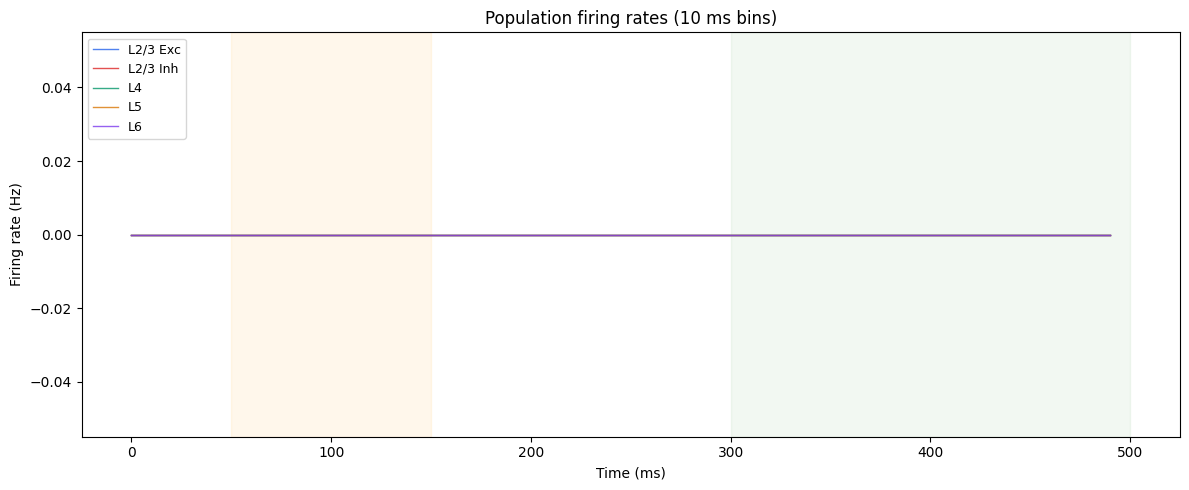

In [4]:
bin_width = 10  # 10 ms bins
n_bins = T // bin_width

fig, ax = plt.subplots(figsize=(12, 5))

for pop, label, colour in zip(populations, pop_labels, colours):
    data = result[pop]
    rate = np.zeros(n_bins)
    for b in range(n_bins):
        t0, t1 = b * bin_width, (b + 1) * bin_width
        rate[b] = data[t0:t1].sum() / (bin_width * 0.001 * col.n_per_layer)
    t_bins = np.arange(n_bins) * bin_width
    ax.plot(t_bins, rate, linewidth=1.0, label=label, color=colour, alpha=0.8)

ax.axvspan(50, 150, alpha=0.08, color='orange')
ax.axvspan(300, 500, alpha=0.05, color='green')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Firing rate (Hz)')
ax.set_title('Population firing rates (10 ms bins)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Feedforward Latency: Thalamus → L4 → L2/3 → L5 → L6

Information propagates through the column with layer-to-layer
delays. We measure the onset latency of each population's
response to the thalamic burst.

In [5]:
onset_threshold = 5  # spikes per bin to count as onset

print(f"{'Population':<12s}  {'Onset (ms)':>10s}  {'Peak rate (Hz)':>14s}")
print("-" * 40)
for pop, label in zip(populations, pop_labels):
    data = result[pop]
    # Find first bin (after stimulus start) with > threshold spikes
    onset = None
    peak_rate = 0
    for b in range(n_bins):
        t0, t1 = b * bin_width, (b + 1) * bin_width
        count = data[t0:t1].sum()
        rate = count / (bin_width * 0.001 * col.n_per_layer)
        peak_rate = max(peak_rate, rate)
        if count >= onset_threshold and onset is None and b * bin_width >= 50:
            onset = b * bin_width
    onset_str = f"{onset} ms" if onset is not None else "none"
    print(f"{label:<12s}  {onset_str:>10s}  {peak_rate:14.1f}")

Population    Onset (ms)  Peak rate (Hz)
----------------------------------------
L2/3 Exc            none             0.0
L2/3 Inh            none             0.0
L4                  none             0.0
L5                  none             0.0
L6                  none             0.0


## Summary

| Layer | Role | Connectivity |
|-------|------|--------------|
| L4 | Thalamic input | Thalamus → L4, L6 → L4 (feedback) |
| L2/3 exc | Recurrent processing | L4 → L2/3, L2/3 ↔ L2/3 |
| L2/3 inh | Local inhibition | L2/3 exc → L2/3 inh → L2/3 exc |
| L5 | Deep output | L2/3 → L5 |
| L6 | Feedback | L5 → L6 → L4 (gain control) |

The canonical microcircuit is a building block for cortical
models. SC-NeuroCore's implementation runs in Python or
compiled to Verilog via the equation-to-hardware pipeline.